In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv("cardekho_dataset.csv")

print(df.shape)
df.head()

(15411, 14)


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [30]:
df = df.drop(df.columns[0], axis=1)  # drops the unnamed index column

print(df.isnull().sum())
print(df.dtypes)

car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64
car_name              object
brand                 object
model                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object


In [31]:
print("Brand:", df['brand'].nunique())
print("Model:", df['model'].nunique())
print("Car name:", df['car_name'].nunique())
print("Fuel type:", df['fuel_type'].unique())
print("Seller type:", df['seller_type'].unique())
print("Transmission:", df['transmission_type'].unique())

Brand: 32
Model: 120
Car name: 121
Fuel type: ['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']
Seller type: ['Individual' 'Dealer' 'Trustmark Dealer']
Transmission: ['Manual' 'Automatic']


In [32]:
df = df.drop(['car_name', 'model'], axis=1)

In [33]:
df[['vehicle_age', 'km_driven', 'selling_price', 'mileage', 'engine', 'max_power']].describe()

,vehicle_age,km_driven,selling_price,mileage,engine,max_power
count,15411.000000,1.541100e+04,1.541100e+04,15411.000000,15411.000000,15411.000000
mean,6.036338,5.561648e+04,7.749711e+05,19.701151,1486.057751,100.588254
std,3.013291,5.161855e+04,8.941284e+05,4.171265,521.106696,42.972979
min,0.000000,1.000000e+02,4.000000e+04,4.000000,793.000000,38.400000
25%,4.000000,3.000000e+04,3.850000e+05,17.000000,1197.000000,74.000000
50%,6.000000,5.000000e+04,5.560000e+05,19.670000,1248.000000,88.500000
75%,8.000000,7.000000e+04,8.250000e+05,22.700000,1582.000000,117.300000
max,29.000000,3.800000e+06,3.950000e+07,33.540000,6592.000000,626.000000


In [34]:
df = df[df['km_driven'] < 500000]
df = df[df['selling_price'] < 10000000]  # adjust based on what you see in describe()
print(df.shape)

(15390, 11)


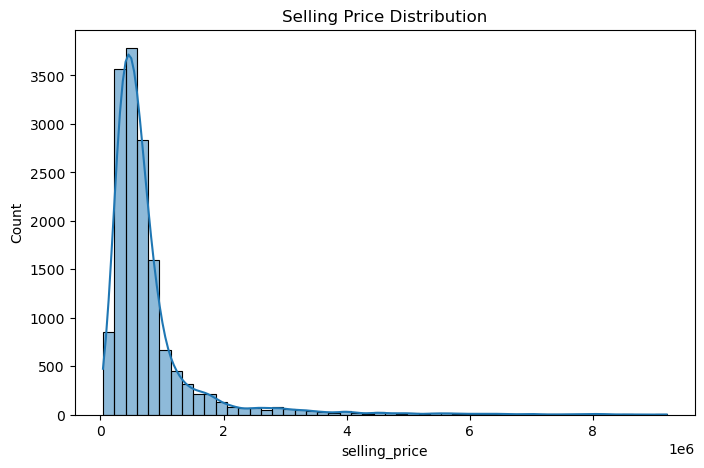

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df['selling_price'], bins=50, kde=True)
plt.title('Selling Price Distribution')
plt.show()

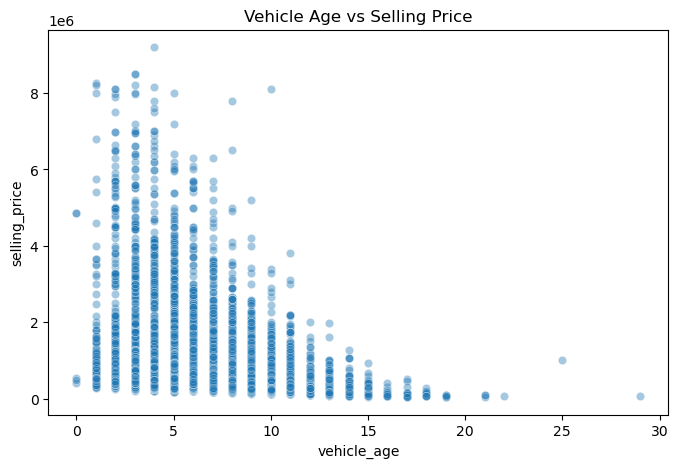

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='vehicle_age', y='selling_price', data=df, alpha=0.4)
plt.title('Vehicle Age vs Selling Price')
plt.show()

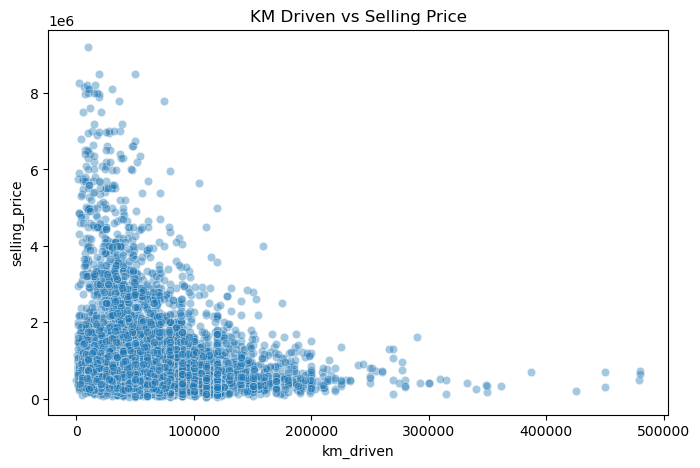

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='km_driven', y='selling_price', data=df, alpha=0.4)
plt.title('KM Driven vs Selling Price')
plt.show()

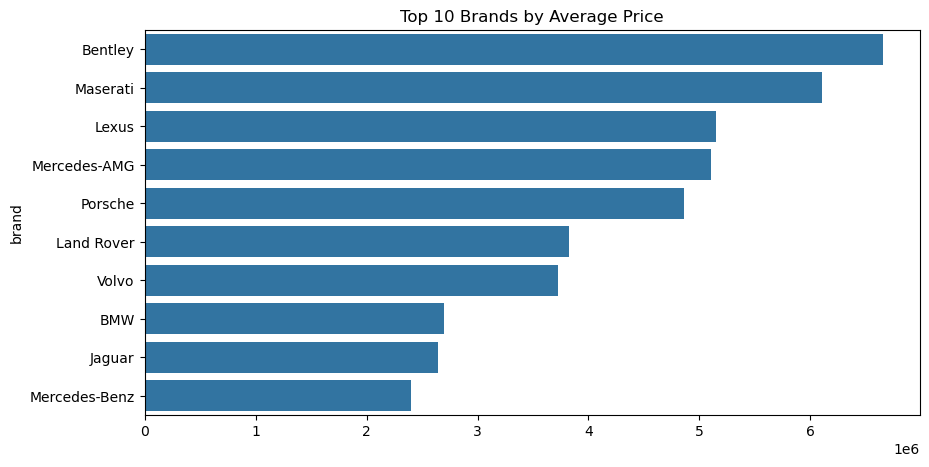

In [38]:
top_brands = df.groupby('brand')['selling_price'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_brands.values, y=top_brands.index)
plt.title('Top 10 Brands by Average Price')
plt.show()

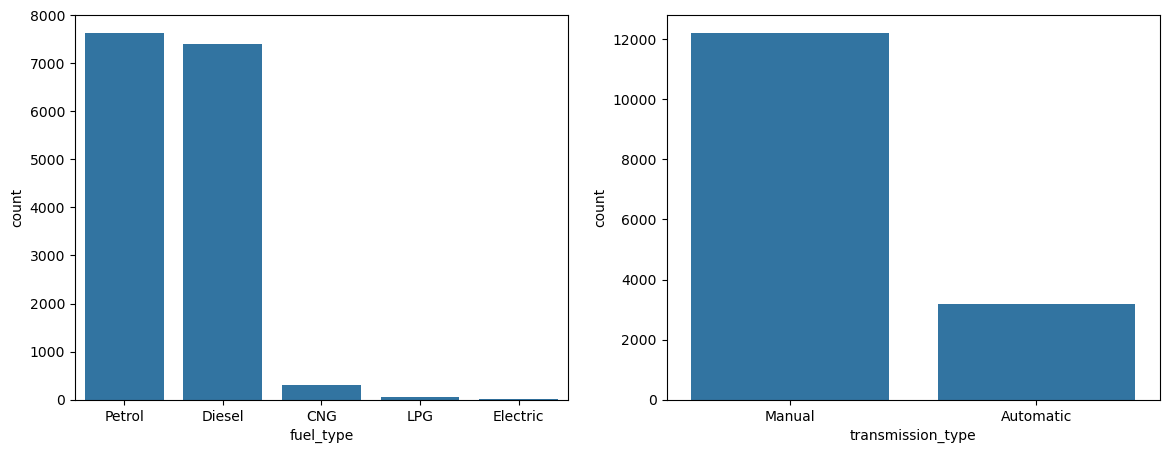

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.countplot(x='fuel_type', data=df, ax=axes[0])
sns.countplot(x='transmission_type', data=df, ax=axes[1])
plt.show()

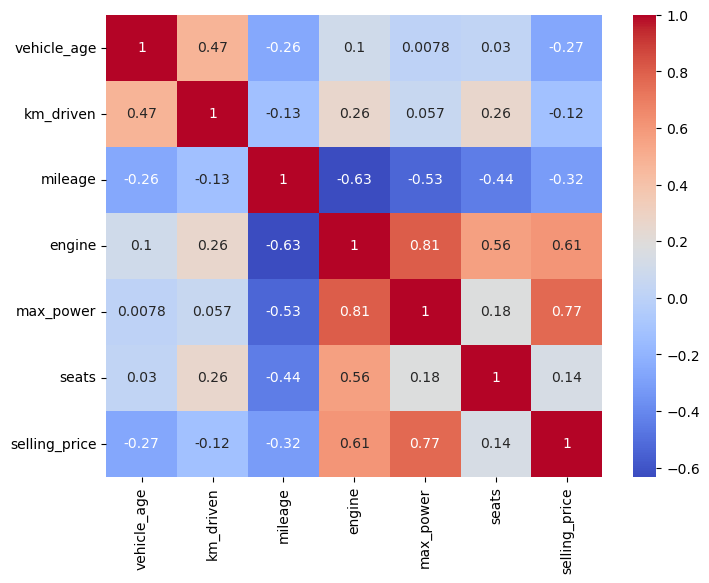

In [40]:
plt.figure(figsize=(8,6))
numeric_cols = ['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

In [41]:
print(df.columns.tolist())
df.dtypes

['brand', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']


brand                 object
vehicle_age            int64
km_driven              int64
seller_type           object
fuel_type             object
transmission_type     object
mileage              float64
engine                 int64
max_power            float64
seats                  int64
selling_price          int64
dtype: object

In [42]:
df = pd.get_dummies(df, columns=['brand', 'seller_type', 'fuel_type', 'transmission_type'], drop_first=True)
print(df.shape)
df.head()

(15390, 43)


,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,brand_BMW,brand_Bentley,brand_Datsun,...,brand_Toyota,brand_Volkswagen,brand_Volvo,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,120000,False,False,False,...,False,False,False,True,False,False,False,False,True,True
1,5,20000,18.90,1197,82.00,5,550000,False,False,False,...,False,False,False,True,False,False,False,False,True,True
2,11,60000,17.00,1197,80.00,5,215000,False,False,False,...,False,False,False,True,False,False,False,False,True,True
3,9,37000,20.92,998,67.10,5,226000,False,False,False,...,False,False,False,True,False,False,False,False,True,True
4,6,30000,22.77,1498,98.59,5,570000,False,False,False,...,False,False,False,False,False,True,False,False,False,True


In [43]:
df.dtypes.value_counts()

bool       36
int64       5
float64     2
Name: count, dtype: int64

In [44]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

print(X.shape, y.shape)

(15390, 42) (15390,)


In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(12312, 42) (3078, 42)


In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
print("Linear Regression R²:", r2_score(y_test, lr_pred))
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))

Linear Regression R²: 0.7476359700381233
Linear Regression RMSE: 429479.56311616424


In [47]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
print("Decision Tree R²:", r2_score(y_test, dt_pred))
print("Decision Tree RMSE:", np.sqrt(mean_squared_error(y_test, dt_pred)))

Decision Tree R²: 0.9037774306409133
Decision Tree RMSE: 265196.1716577979


In [48]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
print("Random Forest R²:", r2_score(y_test, rf_pred))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

Random Forest R²: 0.9497956772004615
Random Forest RMSE: 191557.57580097846


In [49]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R2 Score': [r2_score(y_test, lr_pred), r2_score(y_test, dt_pred), r2_score(y_test, rf_pred)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, lr_pred)), 
              np.sqrt(mean_squared_error(y_test, dt_pred)), 
              np.sqrt(mean_squared_error(y_test, rf_pred))]
})
results

,Model,R2 Score,RMSE
0,Linear Regression,0.747636,429479.563116
1,Decision Tree,0.903777,265196.171658
2,Random Forest,0.949796,191557.575801


In [50]:
import joblib

joblib.dump(rf_model, 'car_price_model.pkl')
print("Model saved!")

Model saved!


In [51]:
import json

columns = {'data_columns': X.columns.tolist()}
with open('columns.json', 'w') as f:
    json.dump(columns, f)

print(len(columns['data_columns']), "columns saved")

42 columns saved


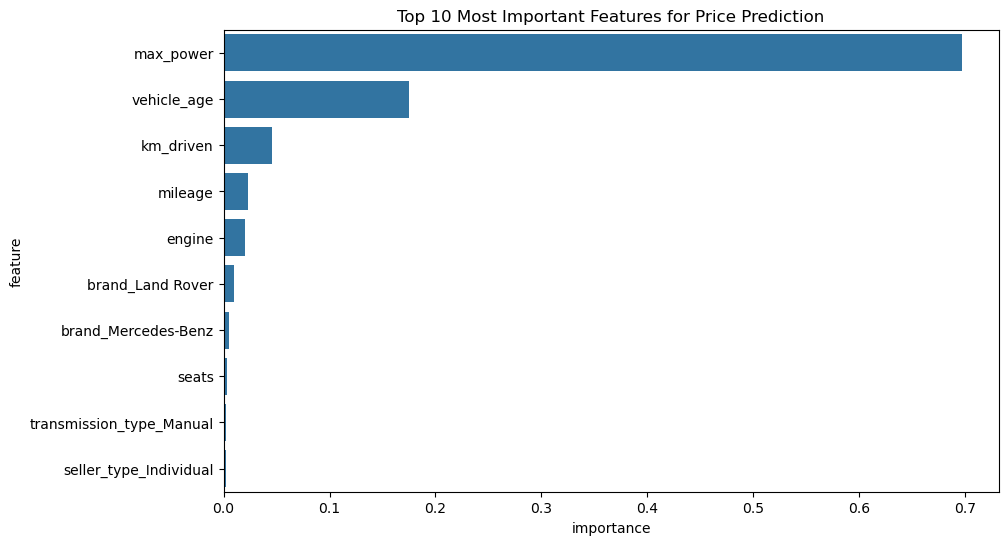

In [52]:
importances = rf_model.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('Top 10 Most Important Features for Price Prediction')
plt.show()

In [53]:
sample = X_test.iloc[0]
actual_price = y_test.iloc[0]
predicted_price = rf_model.predict([sample])[0]

print("Actual price:", actual_price)
print("Predicted price:", predicted_price)

Actual price: 715000
Predicted price: 771500.0


In [54]:
def predict_price_range(input_data):
    tree_predictions = np.array([tree.predict([input_data])[0] for tree in rf_model.estimators_])
    mean_price = tree_predictions.mean()
    lower = np.percentile(tree_predictions, 10)
    upper = np.percentile(tree_predictions, 90)
    return lower, mean_price, upper

lower, mean, upper = predict_price_range(sample.values)
print(f"Price Range: ₹{lower:,.0f} - ₹{upper:,.0f} (estimate: ₹{mean:,.0f})")

Price Range: ₹725,000 - ₹850,000 (estimate: ₹771,500)


    year  predicted_price
0      0    931156.666667
1      1    931156.666667
2      2    915766.666667
3      3    868986.666667
4      4    771500.000000
5      5    727580.000000
6      6    649910.000000
7      7    650200.000000
8      8    511300.000000
9      9    424140.000000
10    10    347944.000000


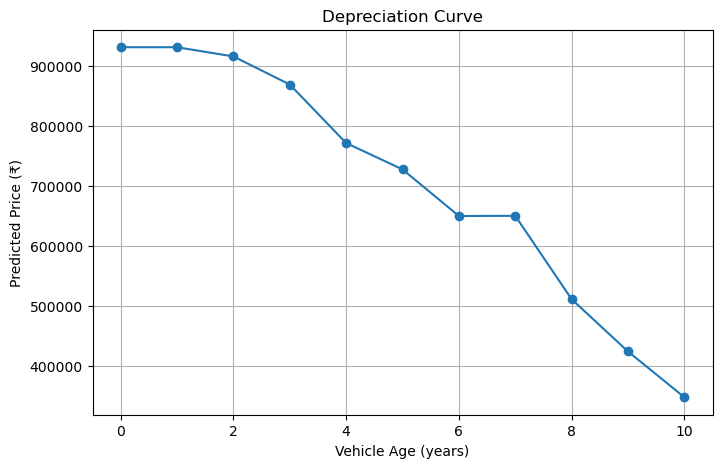

In [55]:
def predict_depreciation(base_row, years=range(0, 11)):
    results = []
    for age in years:
        row = base_row.copy()
        row['vehicle_age'] = age
        price = rf_model.predict([row.values])[0]
        results.append({'year': age, 'predicted_price': price})
    return pd.DataFrame(results)

depreciation_df = predict_depreciation(sample)
print(depreciation_df)

plt.figure(figsize=(8,5))
plt.plot(depreciation_df['year'], depreciation_df['predicted_price'], marker='o')
plt.xlabel('Vehicle Age (years)')
plt.ylabel('Predicted Price (₹)')
plt.title('Depreciation Curve')
plt.grid(True)
plt.show()